In [25]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from config.settings import DATA_DIR

## Guitar Nebula

https://simbad.u-strasbg.fr/simbad/sim-basic?Ident=PSR+2224%2B65&submit=SIMBAD+search

RA: 22 25 52.8627

DEC: +65 35 36.371

GLON: 108.6375752 

GLAT: +06.8455869

NO VISIBLE FERMI-LAT COUNTERPART

SEEN BY CHANDRA !!! AND BY XMM-NEWTON (DATA???)

In [26]:
data = pd.read_csv(f"{DATA_DIR}/b2224/filament.csv")
data.head()

,energy,Flux,Type,Label
0,0.811713,8.819065e-15,0,Data
1,0.811713,1.097723e-14,0,Upper
2,0.811713,6.506992e-15,0,Lower
3,0.887386,3.585729e-15,1,Data
4,0.887386,5.164499e-15,1,Upper


In [27]:
data_data = (data[data["Label"] == "Data"][["energy", "Flux"]]).reset_index(drop=True)
data_upper = (data[data["Label"] == "Upper"][["Flux"]]).reset_index(drop=True)
data_lower = (data[data["Label"] == "Lower"][["Flux"]]).reset_index(drop=True)

In [28]:
data_data["Upper"] = data_upper["Flux"] 
data_data["Lower"] = data_lower["Flux"]

flux = data_data
flux.head()

,energy,Flux,Upper,Lower
0,0.811713,8.819065e-15,1.097723e-14,6.506992e-15
1,0.887386,3.585729e-15,5.164499e-15,1.975944e-15
2,0.970113,1.008141e-14,1.166545e-14,8.198462e-15
3,1.058543,1.180818e-14,1.333521e-14,1.020476e-14
4,1.155033,7.809184e-15,9.036202e-15,6.506992e-15


In [29]:
flux["Flux"] = flux["Flux"] * flux["energy"]**2 * 1e3
flux["Upper"] = flux["Upper"] * flux["energy"]**2 * 1e3
flux["Lower"] = flux["Lower"] * flux["energy"]**2 * 1e3

In [30]:
flux.head()

,energy,Flux,Upper,Lower
0,0.811713,5.810694e-12,7.232666e-12,4.287319e-12
1,0.887386,2.823595e-12,4.066803e-12,1.555964e-12
2,0.970113,9.487801e-12,1.097857e-11,7.715727e-12
3,1.058543,1.323122e-11,1.494227e-11,1.143456e-11
4,1.155033,1.041825e-11,1.205521e-11,8.680989e-12


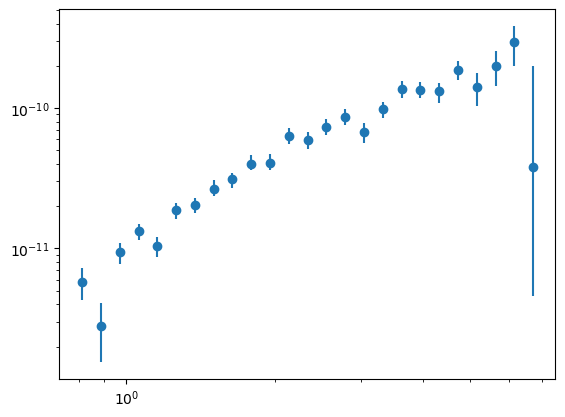

In [31]:
plt.errorbar(flux.energy, flux.Flux, yerr=[flux.Flux - flux.Lower, flux.Upper - flux.Flux], fmt='o')
plt.xscale('log')
plt.yscale('log')